# Исследование отзывов компаний

**Задача:** предсказать оценку от 1 до 5 по тексту отзыва. Метрика соревнования — MAE. Здесь проверяем данные и ищем признаки для модели. Исходные CSV берутся из `data/raw/` и не публикуются в репозитории.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
root = Path.cwd()
if not (root / "data" / "raw" / "train.csv").exists():
    root = root.parent
raw_dir = root / "data" / "raw"
required = [raw_dir / name for name in ("train.csv", "test.csv", "sample_submission.csv")]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Скачайте файлы соревнования Kaggle в data/raw/: {missing}")

train = pd.read_csv(raw_dir / "train.csv")
test = pd.read_csv(raw_dir / "test.csv")
sample = pd.read_csv(raw_dir / "sample_submission.csv")
assert list(train.columns) == ["Id", "Review", "Rating"]
assert list(test.columns) == ["Id", "Review"]
assert list(sample.columns) == ["Id", "Rating"]
assert train["Rating"].isin(range(1, 6)).all()
print(f"Обучение: {len(train):,} строк")
display(train.head(5))
print(f"Тест: {len(test):,} строк")
display(test.head(5))

Обучение: 60,000 строк


,Id,Review,Rating
0,0,Very good value and a great tv very happy and ...,5
1,1,After 6 month still can't access my account,3
2,2,I couldn't make an official review on a produc...,1
3,3,"Fantastic! Extremely easy to use website, fant...",5
4,4,So far annoyed as hell with this bt monthly pa...,1


Тест: 40,000 строк


,Id,Review
0,60000,"Absolutely abysmal. Offered fibre broadband, a..."
1,60001,"Order delivered when promised, effective commu..."
2,60002,I originally contacted your help desk as I tho...
3,60003,To be honest I was a bit worried as these guys...
4,60004,Took out a Vodafone upgrade after receiving a ...


## Качество данных

Проверяем пропуски, идентификаторы и повторы. Полный дубликат совпадает по всем столбцам, включая `Id`. Повтор `Review` — тот же текст, даже если `Id` отличается. Число «лишних копий» не включает первый экземпляр текста; число строк в группах повторов включает все экземпляры.

`Id` нужен для сопоставления строк, но не является признаком модели. Сравнение с `sample_submission.csv` проверяет, что в каждой строке шаблона стоит `Id` соответствующего отзыва из `test.csv`.

In [3]:
quality = pd.DataFrame({
    "набор": ["train", "test"],
    "строк": [len(train), len(test)],
    "уникальных Id": [train["Id"].nunique(), test["Id"].nunique()],
    "пустых Review": [train["Review"].fillna("").str.strip().eq("").sum(),
                       test["Review"].fillna("").str.strip().eq("").sum()],
    "полных дубликатов строк": [train.duplicated().sum(), test.duplicated().sum()],
    "лишних копий Review": [train["Review"].duplicated().sum(),
                             test["Review"].duplicated().sum()],
})
display(quality)

print("Id в test и sample_submission совпадают построчно:",
      test["Id"].equals(sample["Id"]))
repeated_train = train[train.duplicated(subset=["Review"], keep=False)]
print("Строк train в группах повторов Review:", len(repeated_train))
print("Групп повторов Review в train:", repeated_train["Review"].nunique())
print("Повторы Review с разными Rating внутри train:",
      int(train.groupby("Review")["Rating"].nunique().gt(1).sum()))

shared_reviews = set(train["Review"]) & set(test["Review"])
print("Общих уникальных текстов Review в train и test:", len(shared_reviews))
print("Строк test с Review, встречающимся в train:",
      int(test["Review"].isin(shared_reviews).sum()))

,набор,строк,уникальных Id,пустых Review,полных дубликатов строк,лишних копий Review
0,train,60000,60000,0,0,24
1,test,40000,40000,0,0,9


Id в test и sample_submission совпадают построчно: True
Строк train в группах повторов Review: 45
Групп повторов Review в train: 21


Повторы Review с разными Rating внутри train: 0
Общих уникальных текстов Review в train и test: 32
Строк test с Review, встречающимся в train: 33


## Распределение оценок

,строк,"доля, %"
Rating,,
1,18663,31.1
2,1629,2.7
3,1679,2.8
4,3350,5.6
5,34679,57.8


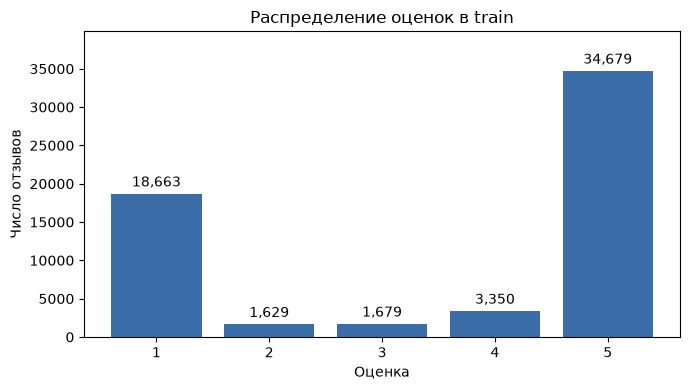

In [4]:
rating_counts = train["Rating"].value_counts().sort_index()
rating_table = pd.DataFrame({
    "строк": rating_counts,
    "доля, %": (100 * rating_counts / len(train)).round(1),
})
display(rating_table)
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#3B6EA8")
ax.bar_label(bars, labels=[f"{n:,}" for n in rating_counts.values], padding=3)
ax.set(xlabel="Оценка", ylabel="Число отзывов", title="Распределение оценок в train")
ax.set_ylim(0, rating_counts.max() * 1.15)
fig.tight_layout()
plt.show()

## Длина отзыва и знаки препинания

Проверяем простые признаки, доступные при инференсе. Наблюдаемая связь с оценкой не означает причинности; полезность признаков подтвердим только сравнением моделей на отложенной выборке.

,train,test
Длина в символах,,
медиана,164,162
90-й процентиль,717,706
99-й процентиль,2110,2115


,median_chars,median_words,exclamation_share,question_share
Rating,,,,
1,424.0,79.0,0.325,0.126
2,317.0,59.0,0.212,0.086
3,235.0,43.0,0.133,0.061
4,159.0,29.0,0.109,0.022
5,104.0,18.0,0.132,0.007


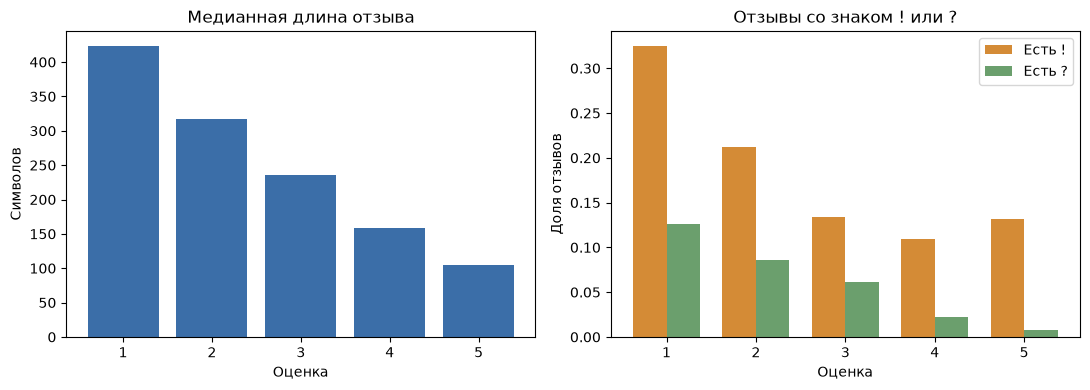

In [5]:
def text_stats(frame: pd.DataFrame) -> pd.DataFrame:
    text = frame["Review"].fillna("")
    return pd.DataFrame({
        "chars": text.str.len(),
        "words": text.str.split().str.len(),
        "has_exclamation": text.str.contains("!", regex=False),
        "has_question": text.str.contains("?", regex=False),
    }, index=frame.index)

train_stats = text_stats(train)
test_stats = text_stats(test)
summary = pd.DataFrame({
    "train": train_stats["chars"].quantile([0.5, 0.9, 0.99]).astype(int),
    "test": test_stats["chars"].quantile([0.5, 0.9, 0.99]).astype(int),
})
summary.index = ["медиана", "90-й процентиль", "99-й процентиль"]
display(summary.rename_axis("Длина в символах"))

by_rating = train_stats.assign(Rating=train["Rating"]).groupby("Rating").agg(
    median_chars=("chars", "median"),
    median_words=("words", "median"),
    exclamation_share=("has_exclamation", "mean"),
    question_share=("has_question", "mean"),
)
display(by_rating.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(by_rating.index.astype(str), by_rating["median_chars"], color="#3B6EA8")
axes[0].set(xlabel="Оценка", ylabel="Символов", title="Медианная длина отзыва")
by_rating[["exclamation_share", "question_share"]].plot.bar(ax=axes[1],
    color=["#D48B36", "#6B9F6D"], width=0.75)
axes[1].set(xlabel="Оценка", ylabel="Доля отзывов", title="Отзывы со знаком ! или ?")
axes[1].legend(["Есть !", "Есть ?"])
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

## Сравнение train и test

Длину в символах мы сравнили выше. Здесь сопоставляем другие признаки текста, доступные в обоих наборах. Поскольку размеры train и test различаются, для знаков препинания и длинных отзывов сравниваем доли. Распределение оценок сравнить нельзя: в test нет `Rating`.

In [6]:
comparison = pd.DataFrame({
    "train": [
        train_stats["words"].median(),
        train_stats["words"].quantile(0.9),
        100 * (train_stats["chars"] > 1000).mean(),
        100 * train_stats["has_exclamation"].mean(),
        100 * train_stats["has_question"].mean(),
    ],
    "test": [
        test_stats["words"].median(),
        test_stats["words"].quantile(0.9),
        100 * (test_stats["chars"] > 1000).mean(),
        100 * test_stats["has_exclamation"].mean(),
        100 * test_stats["has_question"].mean(),
    ],
}, index=[
    "медиана слов",
    "90-й процентиль слов",
    "доля отзывов длиннее 1000 символов, %",
    "доля отзывов со знаком !, %",
    "доля отзывов со знаком ?, %",
])
display(comparison.round(1))

,train,test
медиана слов,29.0,29.0
90-й процентиль слов,133.0,131.0
"доля отзывов длиннее 1000 символов, %",5.5,5.3
"доля отзывов со знаком !, %",19.3,19.1
"доля отзывов со знаком ?, %",4.9,4.6


## Слова, связанные с крайними оценками

Для наглядного сравнения считаем долю отзывов, содержащих слово или биграмму, отдельно среди оценок 1 и 5. Таблица показывает ассоциации в обучающих данных, а не готовые правила для классификации. Оценки 2–4 также останутся при обучении модели.

In [7]:
extreme = train[train["Rating"].isin([1, 5])]
vectorizer = CountVectorizer(stop_words="english", min_df=100, binary=True, ngram_range=(1, 2))
counts = vectorizer.fit_transform(extreme["Review"])
ratings = extreme["Rating"].to_numpy()
count_1 = np.asarray(counts[ratings == 1].sum(axis=0)).ravel()
count_5 = np.asarray(counts[ratings == 5].sum(axis=0)).ravel()
n_1, n_5 = (ratings == 1).sum(), (ratings == 5).sum()
log_odds = np.log((count_5 + 1) / (n_5 - count_5 + 1)) - np.log((count_1 + 1) / (n_1 - count_1 + 1))
terms = vectorizer.get_feature_names_out()
indices = list(np.argsort(log_odds)[:8]) + list(np.argsort(log_odds)[-8:][::-1])
associated_terms = pd.DataFrame({
    "фраза": terms[indices],
    "доля среди 1, %": (100 * count_1[indices] / n_1).round(2),
    "доля среди 5, %": (100 * count_5[indices] / n_5).round(2),
    "сильнее связана с": [1] * 8 + [5] * 8,
})
display(associated_terms)

,фраза,"доля среди 1, %","доля среди 5, %",сильнее связана с
0,joke,4.60,0.01,1
1,terrible customer,1.52,0.00,1
2,worst company,1.50,0.00,1
3,trading standards,1.37,0.00,1
4,absolute joke,1.34,0.00,1
5,disgraceful,1.32,0.00,1
6,disgusting,3.15,0.01,1
7,disgusted,1.04,0.00,1
8,fast delivery,0.03,4.15,5
9,easy use,0.03,3.83,5


## Выводы для моделирования

- Оценки 1 и 5 составляют большую часть обучающих данных (31,1% и 57,8%); оценки 2–4 редки. Основная метрика — MAE, дополнительно посмотрим ошибки по каждой оценке.
- Медианная длина текста падает с 424 символов у оценки 1 до 104 у оценки 5. Длину и количество слов стоит проверить как признаки рядом с текстовым TF-IDF.
- Вопросительные и восклицательные знаки чаще встречаются в низких оценках. Проверим их как бинарные признаки.
- Характерные слова и биграммы различаются у оценок 1 и 5. Основным текстовым представлением попробуем TF-IDF по словам и биграммам.
- Полных дубликатов строк в train нет: `Id` различаются. Есть 24 лишние копии `Review`, причём одинаковым текстам соответствуют одинаковые `Rating`. Перед разделением на обучение и валидацию удалим повторные тексты из рабочей копии train; исходный CSV не меняем. Так повторы не получат дополнительный вес и не попадут по обе стороны разделения.
- В train и Kaggle test совпадают 32 уникальных текста (33 строки test). Эти строки остаются в test: файл отправки должен содержать предсказание для каждого `Id` из `sample_submission.csv`. Совпадения могут немного облегчить оценку Kaggle, поэтому качество на новых текстах будем судить прежде всего по локальной валидации.
- По длине и знакам препинания train и test близки. Заметного сдвига по рассмотренным признакам нет, но это не исключает различий в словаре.